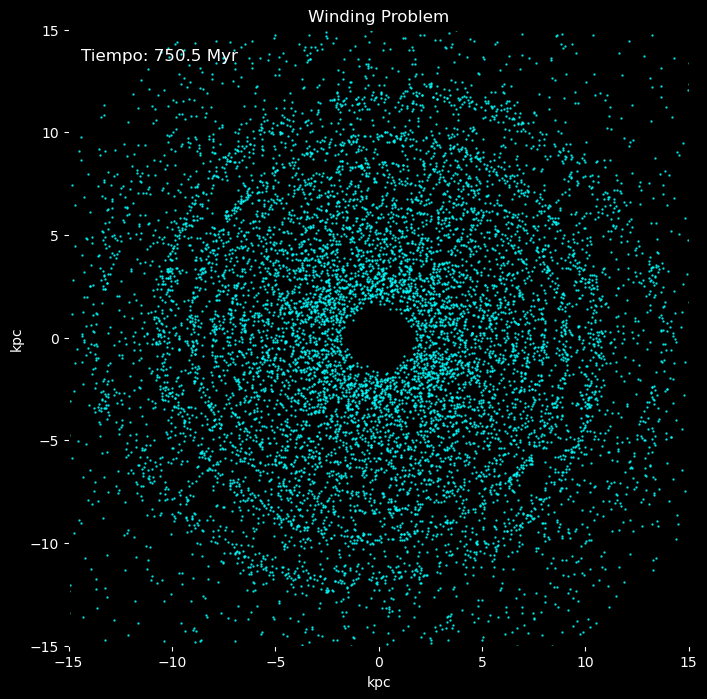

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Constantes físicas en unidades SI
kpc0 = 3.085677581e19        
Myr0 = 3.15576e13            
G0 = 6.67430e-11             
M_sol0 = 1.989e30 
M_gal0 = 1e11 * M_sol0 

# Reescalamiento
c = kpc0                  
M_gal = M_gal0              
T_scale = np.sqrt(c**3 / (G0 * M_gal)) 

kpc = kpc0 / c           # kpc será 1
M_gal = M_gal0 / M_gal   # M_gal será 1
G = 1.0
Myr = Myr0 / T_scale     # unidad de tiempo reescalada

# Configuración de la galaxia
num_brazos = 2    
N_por_brazo = 5000  
dt = 0.5 * Myr  
nsteps = 1500 

# Cálculo aceleración
def acceleration(pos):
    r2 = np.sum(pos**2, axis=1)
    r = np.sqrt(r2)
    a = -G * M_gal * pos / r[:, None]**3 
    return a

# CONDICIONES HÍBRIDAS: Geometría Lin-Shu + Cinemática Kepleriana
def make_hybrid_conditions(N_per_arm, m_arms):
    todas_posiciones = []

    # 1. GEOMETRÍA (Elipses de Lin-Shu)
    r = np.random.uniform(2.0, 14.0, N_per_arm) 
    e = 0.08 + 0.32 * np.random.rand(N_per_arm) 
    phi = 0.55 * (r / kpc) 
    nu = np.random.uniform(0, 2*np.pi, N_per_arm) 
    
    a = r / (1 - e**2) 
    rr = a * (1 - e**2) / (1 + e * np.cos(nu)) 
    
    x_orb = rr * np.cos(nu)
    y_orb = rr * np.sin(nu)
    
    c_ang = np.cos(phi)
    s_ang = np.sin(phi)
    x1 = c_ang * x_orb - s_ang * y_orb
    y1 = s_ang * x_orb + c_ang * y_orb
    pos1 = np.column_stack((x1, y1))

    for k in range(m_arms):
        theta = k * (2 * np.pi / m_arms)
        c_rot = np.cos(theta)
        s_rot = np.sin(theta)
        
        x_rot = c_rot * pos1[:, 0] - s_rot * pos1[:, 1]
        y_rot = s_rot * pos1[:, 0] + c_rot * pos1[:, 1]
        pos_k = np.column_stack((x_rot, y_rot))
        todas_posiciones.append(pos_k)

    # Matriz final de posiciones (Mantenemos la onda de densidad visualmente)
    pos_final = np.vstack(todas_posiciones)

    # 2. CINEMÁTICA "INCORRECTA" (Rotación Kepleriana circular)
    # Calculamos el radio real absoluto de cada estrella en su posición actual
    r_mag = np.sqrt(np.sum(pos_final**2, axis=1))
    
    # Imponemos velocidad circular v = sqrt(GM/r)
    v_mag = np.sqrt(G * M_gal / r_mag)
    
    # Calculamos componentes X e Y tangentes a la órbita circular (antihorario)
    vx_circ = -v_mag * (pos_final[:, 1] / r_mag)
    vy_circ =  v_mag * (pos_final[:, 0] / r_mag)
    vel_final = np.column_stack((vx_circ, vy_circ))

    return pos_final, vel_final

# Velocidad Verlet
def verlet_step(pos, vel):
    a = acceleration(pos)
    pos_new = pos + vel * dt + 0.5 * a * dt**2
    a_new = acceleration(pos_new)
    vel_new = vel + 0.5 * (a + a_new) * dt
    return pos_new, vel_new

# Inicialización
pos, vel = make_hybrid_conditions(N_por_brazo, num_brazos)

# Construimos la figura
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor("black")
fig.patch.set_facecolor("black")

scatter = ax.scatter(
    pos[:, 0] / kpc,
    pos[:, 1] / kpc,
    s=0.5,
    color='cyan',
    alpha=0.8
)

ax.set_xlim(-15, 15) 
ax.set_ylim(-15, 15)
ax.set_xlabel("kpc", color="white")
ax.set_ylabel("kpc", color="white")
ax.tick_params(colors="white")
ax.set_title("Winding Problem", color="white")

time_text = ax.text(
    0.02, 0.95, "",
    transform=ax.transAxes,
    color="white", fontsize=12
)

# Animación
t = 0.0

def update(frame):
    global pos, vel, t
    pasos_por_frame = 1

    for _ in range(pasos_por_frame):
        pos, vel = verlet_step(pos, vel)
        t += dt

    scatter.set_offsets(pos / kpc)
    time_text.set_text(f"Tiempo: {t/Myr:.1f} Myr")
    return scatter, time_text

ani = FuncAnimation(
    fig,
    update,
    frames=nsteps,
    interval=25,
    blit=False
)
ani.save("hibrido_winding_problem.gif", writer='pillow', fps=30)
plt.show()